In [ ]:
import os
import re
import sys
import json
import random
import subprocess
import numpy as np
import pandas as pd
from tqdm import tqdm
from simple_colors import *
import os
import fnmatch

import pandas as pd
from collections import defaultdict

module_path = os.path.abspath(os.path.join(''))
if module_path not in sys.path:
    sys.path.append(module_path)


%load_ext autoreload
%autoreload 2

from utils import load_jsonlines, write_jsonlines, PROJECT_ROOT_DIR, DATA_ROOT_DIR, load_json, write_json

AskEconomics: 1781 sequences, 9984 tokens, n=2
AskHistorians: 1867 sequences, 12154 tokens, n=2
asklinguistics: 1901 sequences, 8454 tokens, n=2
history: 2086 sequences, 9365 tokens, n=2
ScienceBasedParenting: 2789 sequences, 13855 tokens, n=2
beyondthebump: 2132 sequences, 9007 tokens, n=2
explainlikeimfive: 2190 sequences, 11156 tokens, n=2
NoStupidQuestions: 2068 sequences, 7125 tokens, n=2
OutOfTheLoop: 2123 sequences, 10138 tokens, n=2


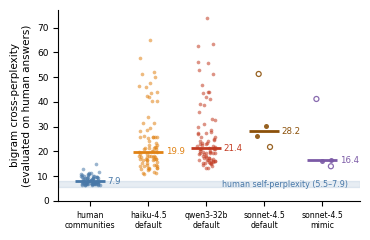

<Axes: ylabel='bigram cross-perplexity\n(evaluated on human answers)'>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

community_names = ["AskEconomics", "AskHistorians", "asklinguistics", "history",
                   "ScienceBasedParenting", "beyondthebump", "explainlikeimfive",
                   "NoStupidQuestions", "OutOfTheLoop"]

humans = {name: load_jsonlines(f"answer_tagging/results/{name}/comments_tagged.jsonl")
          for name in community_names}
haiku = {f"haiku-{name}": load_jsonlines(f"answer_tagging/results/{name}/claude-haiku-4.5_tagged.jsonl")
         for name in community_names}
qwen = {f"qwen-{name}": load_jsonlines(f"answer_tagging/results/{name}/Qwen3-32B_processed_tagged.jsonl")
        for name in community_names}
mimicked = {f"sonnet-mimic-{name}": load_jsonlines(f"answer_tagging/results/{name}/claude-sonnet-4.5_mimic_community_guidelines_tagged.jsonl")
            for name in ["AskHistorians", "ScienceBasedParenting"]}
sonnet = {f"sonnet-{name}": load_jsonlines(f"answer_tagging/results/{name}/claude-sonnet-4.5_tagged.jsonl")
          for name in ["AskHistorians", "ScienceBasedParenting"]}

# Train models
def build_models(communities, n=2):
    seqs = {name: extract_sequences(qs) for name, qs in communities.items()}
    models = {}
    for name, s in seqs.items():
        m = NgramModel(n=n)
        m.train(s)
        models[name] = m
    return models, seqs

def cross_matrix(train_models, eval_seqs):
    rows, cols = sorted(train_models), sorted(eval_seqs)
    mat = pd.DataFrame(
        [[train_models[t].perplexity(eval_seqs[e]) for e in cols] for t in rows],
        index=rows, columns=cols)
    mat.index.name, mat.columns.name = "train", "eval"
    return mat

# human human 
human_models2, human_seqs2, human_matrix2 = train_and_compare(humans, n=2)

# LLM-trained models, evaluated on human answers
haiku_models2, _  = build_models(haiku, n=2)
qwen_models2, _   = build_models(qwen, n=2)
sonnet_models2, _ = build_models(sonnet, n=2)
mimic_models2, _  = build_models(mimicked, n=2)

mimic_communities = {k: human_seqs2[k] for k in ["AskHistorians", "ScienceBasedParenting"]}

haiku_vs_human  = cross_matrix(haiku_models2, human_seqs2)         
qwen_vs_human   = cross_matrix(qwen_models2, human_seqs2)          
sonnet_vs_human = cross_matrix(sonnet_models2, mimic_communities)  
mimic_vs_human  = cross_matrix(mimic_models2, mimic_communities)   

def plot_diversity_gap(human_matrix, llm_groups, ax=None, fig_size=(3.4, 2.9),
                       matched_marker_max=12, save=False,
                       save_name="diversity_gap.pdf"):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=fig_size)

    def split_matched(m):
        matched, mismatched = [], []
        for r in m.index:
            for c in m.columns:
                v = m.loc[r, c]
                (matched if (r == c or r.endswith("-" + c)) else mismatched).append(v)
        return np.array(matched), np.array(mismatched)

    offdiag  = human_matrix.values[~np.eye(len(human_matrix), dtype=bool)]
    self_ppl = np.diag(human_matrix.values)

    groups = [("human\ncommunities", (np.array([]), offdiag), "#4878a8")]
    groups += [(label, split_matched(m), c) for label, m, c in llm_groups]

    # the shaded band is the range of human self-perplexity range
    ax.axhspan(self_ppl.min(), self_ppl.max(), color="#4878a8", alpha=0.13, zorder=0)
    ax.text(len(groups) - 0.55, (self_ppl.min() + self_ppl.max()) / 2,
            f"human self-perplexity ({self_ppl.min():.1f}\u2013{self_ppl.max():.1f})",
            fontsize=5.8, color="#4878a8", ha="right", va="center", zorder=1)

    rng = np.random.default_rng(0)
    for x, (label, (matched, mismatched), color) in enumerate(groups):
        vals = np.concatenate([matched, mismatched])
        distinguish = 0 < len(vals) <= matched_marker_max and len(matched) > 0
        if distinguish:
            jm = rng.uniform(-0.16, 0.16, size=len(matched))
            jx = rng.uniform(-0.16, 0.16, size=len(mismatched))
            ax.scatter(x + jm, matched, s=13, color=color, alpha=0.9,
                       linewidths=0, zorder=2)                     # filled = matched
            ax.scatter(x + jx, mismatched, s=13, facecolors="none",
                       edgecolors=color, alpha=0.9, linewidths=0.9,
                       zorder=2)                                   # open = mismatched
        else:
            jit = rng.uniform(-0.16, 0.16, size=len(vals))
            ax.scatter(x + jit, vals, s=7, color=color, alpha=0.55,
                       linewidths=0, zorder=2)
        med = np.median(vals)
        ax.hlines(med, x - 0.26, x + 0.26, color=color, lw=2.0, zorder=3)
        ax.annotate(f"{med:.1f}", (x + 0.30, med), fontsize=6.2,
                    color=color, va="center")

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([g[0] for g in groups], fontsize=5.6)
    ax.set_ylabel("bigram cross-perplexity\n(evaluated on human answers)", fontsize=7.5)
    ax.tick_params(axis="y", labelsize=6.5)
    ax.set_ylim(0, None)
    ax.set_xlim(-0.55, len(groups) - 0.35)
    ax.spines[["top", "right"]].set_visible(False)

    if standalone:
        plt.tight_layout()
        if save:
            plt.savefig(save_name, bbox_inches="tight")
        plt.show()
    return ax

plot_diversity_gap(
    human_matrix2,
    fig_size=(3.8, 2.5),
    llm_groups=[
        ("haiku-4.5\ndefault",  haiku_vs_human,  "#e08214"),
        ("qwen3-32b\ndefault",  qwen_vs_human,   "#c23b22"),
        ("sonnet-4.5\ndefault", sonnet_vs_human, "#8c510a"),
        ("sonnet-4.5\nmimic",   mimic_vs_human,  "#7b5aa6"),
    ],
    save=True, save_name="diversity_gap.pdf",
)